# 📐 Task 1 — Steps 4 & 5: Spatial Sensitivity (Translation & Patch Scrambling)

## 1. Overview & Theoretical Motivation
A foundational distinction between Convolutional Networks and Vision Transformers lies in how they encode spatial structure:
1. **Convolutions**: Provide translational equivariance priors via localized weight sharing. However, striding, pooling, and edge-padding introduce subtle position sensitivities.
2. **Vision Transformers**: Process disjoint patches via global self-attention with absolute positional encodings ($1$D or $2$D). They lack strict translational equivariance priors.

### Interventions Tested
1. **Translation Equivariance / Stability**:
   - Displacements: $\delta \in \{0, 8, 16, 32\}$ pixels ($0\%, 3.5\%, 7.1\%, 14.3\%$ of image width).
   - Directions: $4$ cardinal directions (Up, Down, Left, Right).
   - Reflection padding followed by shifted cropping.
   - Results averaged across the $4$ cardinal directions.
   $$\text{Consistency}(\delta) = \frac{1}{N} \sum_{i=1}^N \mathbf{1}[\hat{y}(x_i) == \hat{y}(T_\delta(x_i))]$$

2. **Patch Structure Disruption (Patch Scrambling)**:
   - $4 \times 4$ pixel-space grid ($16$ patches of $56 \times 56$ pixels).
   - One non-identity permutation per image using Seed `6304`.
   - Destroys global spatial topology while retaining local pixel textures.

### Hypotheses
- **Translation**: ResNet-50 will exhibit strong stability under small shifts (8px), but may degrade under larger shifts (32px) due to boundary padding artifacts. ViT-B/16 may show continuous decay due to discrete patch grid alignment.
- **Patch Scrambling**: Models relying heavily on global shape will experience severe accuracy collapse. Models relying on local texture shortcuts will retain higher accuracy on classes with distinctive surface patterns.


In [1]:
import sys, os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..', '..')))

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import f1_score
from tqdm.auto import tqdm

from shared.src.seed import set_seed, SEED
set_seed(6304)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device} | Seed: {SEED}")


Using device: cuda | Seed: 6304


## 2. Load Evaluation Subset, Clean Baseline Predictions & Models


In [2]:
from task1_inductive_biases.src.data import load_stl10, STL10_CLASSES
from task1_inductive_biases.src.backbones import (
    ResNet50Backbone, ViTB16Backbone, CLIPBackbone, LinearHead,
    RESNET_NORM, VIT_NORM, CLIP_NORM
)
from task1_inductive_biases.src.transforms import translate, shuffle_patches

_, test_ds, class_names = load_stl10(root='../../data/stl10')
eval_indices = np.load('../cache/eval_indices.npy')
eval_labels  = np.load('../cache/eval_labels.npy')
eval_sub     = Subset(test_ds, eval_indices.tolist())

backbones = {
    'ResNet-50': ResNet50Backbone().to(device),
    'ViT-B/16':  ViTB16Backbone().to(device),
    'CLIP':      CLIPBackbone().to(device),
}
norms = {'ResNet-50': RESNET_NORM, 'ViT-B/16': VIT_NORM, 'CLIP': CLIP_NORM}

heads = {}
for name, bb in backbones.items():
    safe = name.replace('/', '_').replace(' ', '_')
    head = LinearHead(bb.dim, 10).to(device)
    head.load_state_dict(torch.load(f'../cache/head_{safe}.pth', map_location=device))
    head.eval()
    heads[name] = head

clean_preds = {
    'ResNet-50': np.load('../cache/clean_preds_ResNet-50.npy'),
    'ViT-B/16':  np.load('../cache/clean_preds_ViT-B_16.npy'),
    'CLIP':      np.load('../cache/clean_preds_CLIP.npy'),
    'CLIP-ZS':   np.load('../cache/clean_preds_CLIP-ZS.npy'),
}

print(f"✅ Loaded models and clean baseline predictions for {len(eval_sub)} evaluation images.")


Loading fast pre-cached STL-10:
  Train: ..\..\data\stl10_train_fast.pt
  Test:  ..\..\data\stl10_test_fast.pt


c:\Users\moize\anaconda3\envs\geo\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


✅ Loaded models and clean baseline predictions for 500 evaluation images.


C:\Users\moize\AppData\Local\Temp\ipykernel_16676\2707878962.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  head.load_state_dict(torch.load(f'../cache/head_{safe}.pth'

## 3. Translation Experiment Generation & Matrix Gallery
We translate every image by $\delta \in \{0, 8, 16, 32\}$ pixels across 4 directions: `up`, `down`, `left`, `right`.


In [3]:
OFFSETS    = [0, 8, 16, 32]
DIRECTIONS = ['up', 'down', 'left', 'right']

print("Generating translated image sets...")
translated_images = {}  # (delta, direction) -> list of image tensors

for delta in OFFSETS:
    for direction in DIRECTIONS:
        imgs = []
        for i in range(len(eval_sub)):
            img, _ = eval_sub[i]
            imgs.append(translate(img, delta, direction))
        translated_images[(delta, direction)] = imgs
        print(f"  δ={delta:2d}px {direction:>5s}: {len(imgs)} images")

print("✅ All translation variations generated.")


Generating translated image sets...
  δ= 0px    up: 500 images
  δ= 0px  down: 500 images
  δ= 0px  left: 500 images
  δ= 0px right: 500 images
  δ= 8px    up: 500 images
  δ= 8px  down: 500 images
  δ= 8px  left: 500 images
  δ= 8px right: 500 images
  δ=16px    up: 500 images
  δ=16px  down: 500 images
  δ=16px  left: 500 images
  δ=16px right: 500 images
  δ=32px    up: 500 images
  δ=32px  down: 500 images
  δ=32px  left: 500 images
  δ=32px right: 500 images
✅ All translation variations generated.


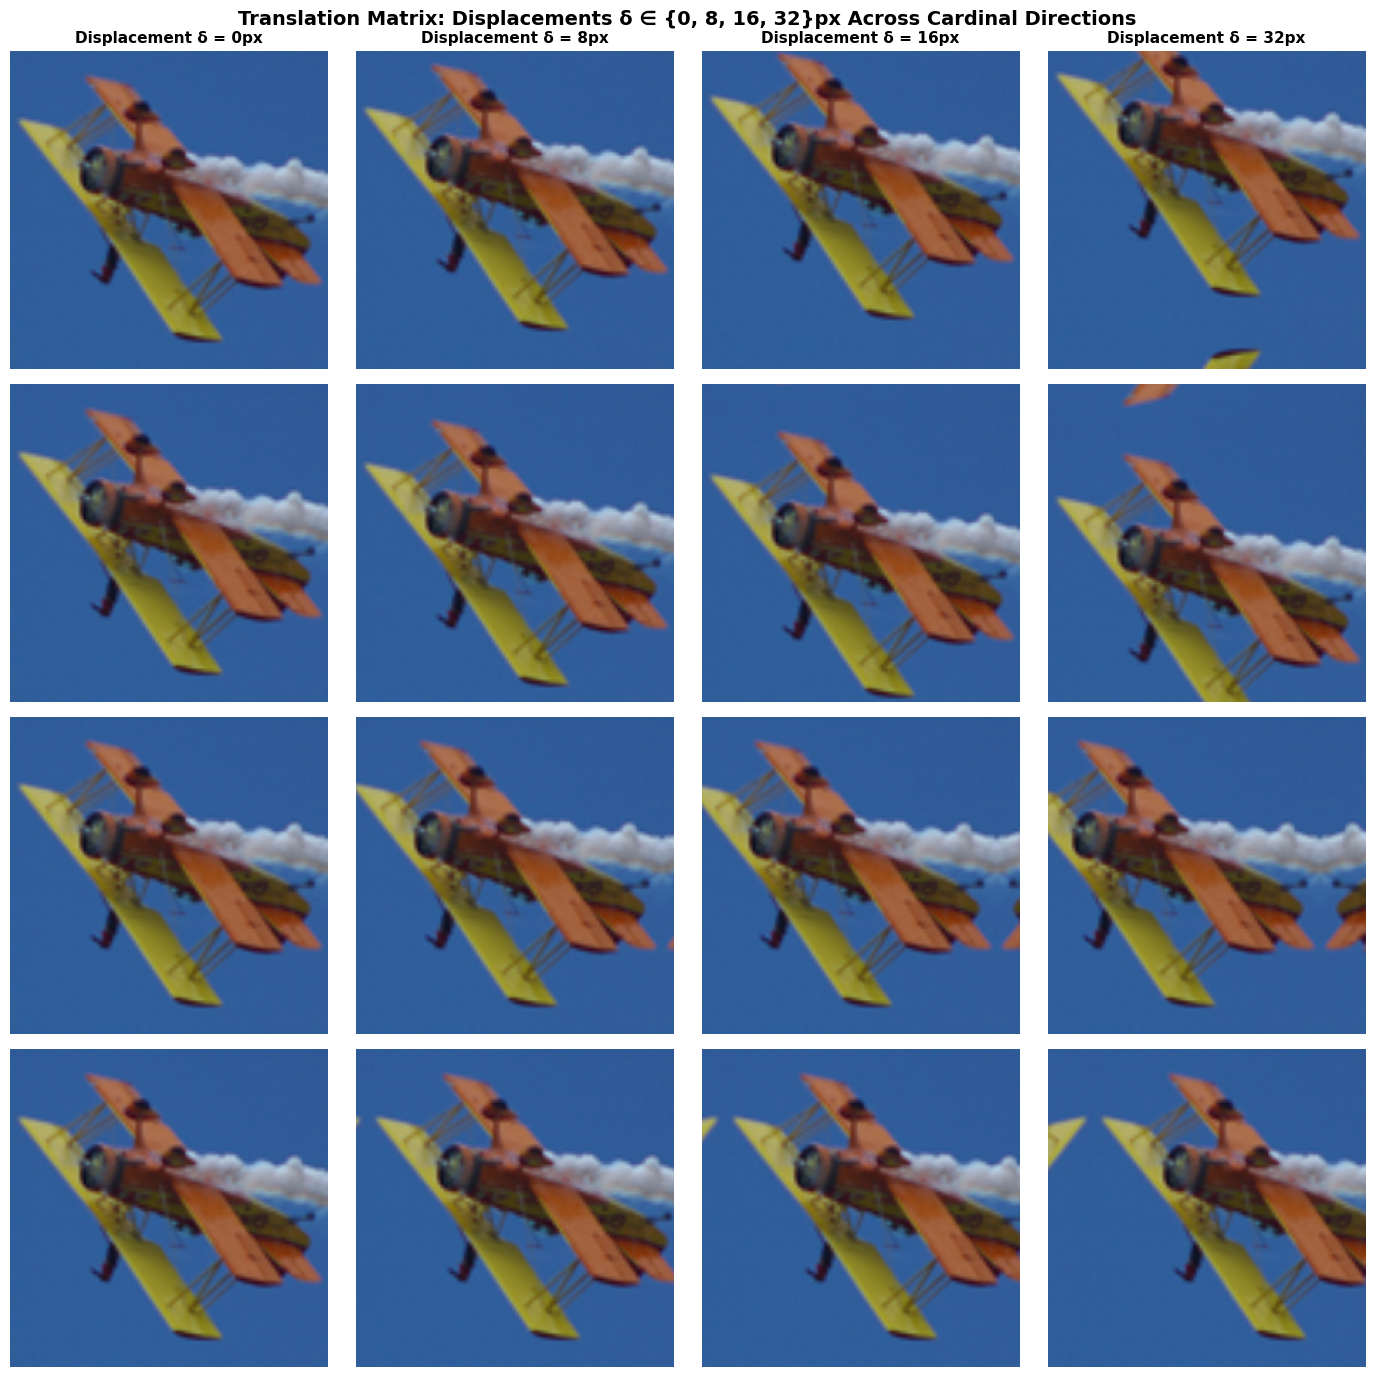

In [4]:
# 4x4 Translation Matrix Gallery
fig, axes = plt.subplots(4, 4, figsize=(14, 14))
fig.suptitle("Translation Matrix: Displacements δ ∈ {0, 8, 16, 32}px Across Cardinal Directions", fontsize=14, fontweight='bold')
sample_idx = 0

for row_idx, direction in enumerate(DIRECTIONS):
    for col_idx, delta in enumerate(OFFSETS):
        ax = axes[row_idx, col_idx]
        t_img = translated_images[(delta, direction)][sample_idx]
        ax.imshow(t_img.permute(1, 2, 0).clamp(0, 1).numpy())
        if row_idx == 0:
            ax.set_title(f"Displacement δ = {delta}px", fontsize=11, fontweight='bold')
        if col_idx == 0:
            ax.set_ylabel(direction.upper(), fontsize=12, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.savefig('../results/translation_matrix_gallery.png', dpi=200, bbox_inches='tight')
plt.show()


## 4. Evaluate Models Across Translation Displacements
We evaluate all 4 models at each displacement $\delta$, averaging accuracy and consistency across cardinal directions.


In [5]:
def predict_image_batch(backbone, norm, head, images, batch_size=64):
    all_preds = []
    backbone.eval()
    if head is not None: head.eval()
    for i in range(0, len(images), batch_size):
        batch = torch.stack(images[i:i+batch_size])
        batch = torch.stack([norm(img) for img in batch]).to(device)
        with torch.no_grad():
            feats = backbone(batch)
            logits = head(feats)
            preds = logits.argmax(dim=1).cpu()
            all_preds.append(preds)
    return torch.cat(all_preds).numpy()


def predict_clip_zs_batch(clip_backbone, norm, images, class_names, batch_size=64):
    prompts = [f"a photo of a {c}." for c in class_names]
    text_feats = clip_backbone.encode_text(prompts)
    all_preds = []
    clip_backbone.eval()
    for i in range(0, len(images), batch_size):
        batch = torch.stack(images[i:i+batch_size])
        batch = torch.stack([norm(img) for img in batch]).to(device)
        with torch.no_grad():
            img_feats = clip_backbone(batch)
            sim = (img_feats @ text_feats.T) * 100.0
            preds = sim.argmax(dim=1).cpu()
            all_preds.append(preds)
    return torch.cat(all_preds).numpy()

# Run translation evaluation
trans_metrics = {m: {'acc': [], 'consistency': []} for m in ['ResNet-50', 'ViT-B/16', 'CLIP', 'CLIP-ZS']}
direction_metrics = {m: {d: [] for d in DIRECTIONS} for m in trans_metrics}

for delta in OFFSETS:
    for mkey in trans_metrics:
        dir_accs = []
        dir_cons = []
        for d in DIRECTIONS:
            imgs = translated_images[(delta, d)]
            if mkey == 'CLIP-ZS':
                preds = predict_clip_zs_batch(backbones['CLIP'], norms['CLIP'], imgs, class_names)
            else:
                preds = predict_image_batch(backbones[mkey], norms[mkey], heads[mkey], imgs)
            
            acc = np.mean(preds == eval_labels)
            cons = np.mean(preds == clean_preds[mkey])
            dir_accs.append(acc)
            dir_cons.append(cons)
            direction_metrics[mkey][d].append(acc)
            
        trans_metrics[mkey]['acc'].append(np.mean(dir_accs))
        trans_metrics[mkey]['consistency'].append(np.mean(dir_cons))

print("Translation Evaluation Summary:")
for mkey in trans_metrics:
    acc_str = ", ".join([f"δ={d}px: {a:.3f}" for d, a in zip(OFFSETS, trans_metrics[mkey]['acc'])])
    print(f"  {mkey:>12s} -> {acc_str}")


Translation Evaluation Summary:
     ResNet-50 -> δ=0px: 0.970, δ=8px: 0.963, δ=16px: 0.962, δ=32px: 0.956
      ViT-B/16 -> δ=0px: 0.972, δ=8px: 0.969, δ=16px: 0.972, δ=32px: 0.967
          CLIP -> δ=0px: 0.968, δ=8px: 0.965, δ=16px: 0.959, δ=32px: 0.950
       CLIP-ZS -> δ=0px: 0.934, δ=8px: 0.944, δ=16px: 0.941, δ=32px: 0.922


## 5. Translation Sensitivity Curves
We plot **Accuracy vs. Displacement $\delta$** and **Prediction Consistency vs. Displacement $\delta$**.


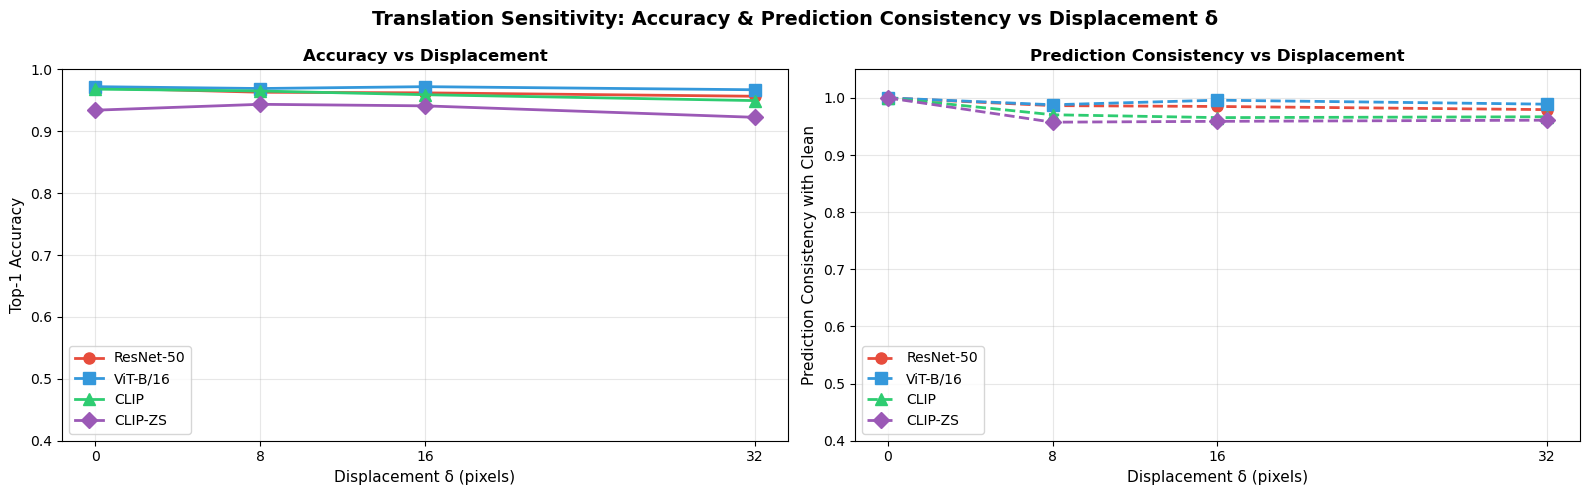

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Translation Sensitivity: Accuracy & Prediction Consistency vs Displacement δ", fontsize=14, fontweight='bold')
palette = {'ResNet-50': '#e74c3c', 'ViT-B/16': '#3498db', 'CLIP': '#2ecc71', 'CLIP-ZS': '#9b59b6'}
markers = {'ResNet-50': 'o', 'ViT-B/16': 's', 'CLIP': '^', 'CLIP-ZS': 'D'}

# Panel 1: Accuracy vs Displacement
ax = axes[0]
for mkey in trans_metrics:
    ax.plot(OFFSETS, trans_metrics[mkey]['acc'], marker=markers[mkey], color=palette[mkey],
            linewidth=2, markersize=8, label=mkey)
ax.set_xlabel("Displacement δ (pixels)", fontsize=11)
ax.set_ylabel("Top-1 Accuracy", fontsize=11)
ax.set_title("Accuracy vs Displacement", fontsize=12, fontweight='bold')
ax.set_xticks(OFFSETS)
ax.set_ylim(0.4, 1.0)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Panel 2: Consistency vs Displacement
ax = axes[1]
for mkey in trans_metrics:
    ax.plot(OFFSETS, trans_metrics[mkey]['consistency'], marker=markers[mkey], color=palette[mkey],
            linewidth=2, linestyle='--', markersize=8, label=mkey)
ax.set_xlabel("Displacement δ (pixels)", fontsize=11)
ax.set_ylabel("Prediction Consistency with Clean", fontsize=11)
ax.set_title("Prediction Consistency vs Displacement", fontsize=12, fontweight='bold')
ax.set_xticks(OFFSETS)
ax.set_ylim(0.4, 1.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/translation_curves.png', dpi=200, bbox_inches='tight')
plt.show()


## 6. Directional Sensitivity Analysis
We evaluate whether any model shows directional asymmetry (e.g., vertical vs. horizontal displacement sensitivity).


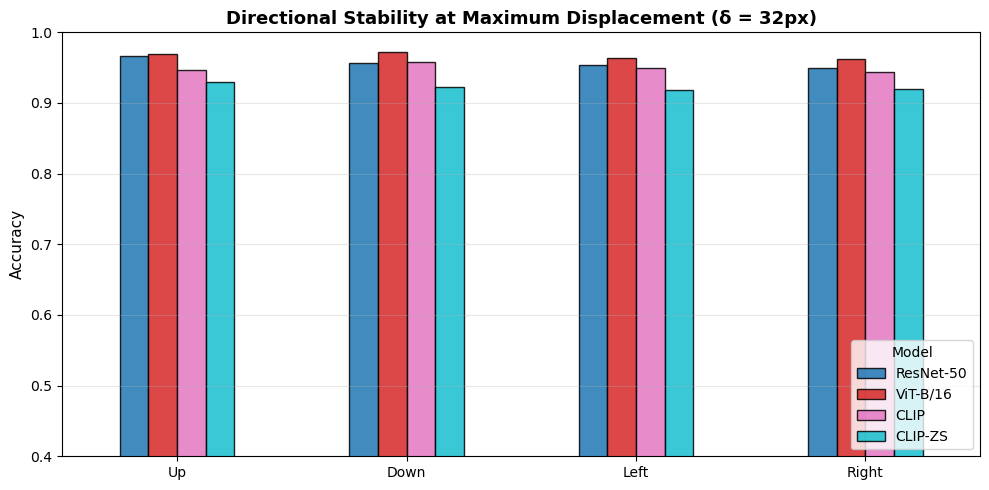

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
dir_32px = {m: [direction_metrics[m][d][-1] for d in DIRECTIONS] for m in trans_metrics}
df_dir = pd.DataFrame(dir_32px, index=[d.capitalize() for d in DIRECTIONS])

df_dir.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='black', alpha=0.85)
ax.set_title("Directional Stability at Maximum Displacement (δ = 32px)", fontsize=13, fontweight='bold')
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_ylim(0.4, 1.0)
ax.grid(axis='y', alpha=0.3)
ax.legend(title="Model", loc='lower right')
plt.xticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.savefig('../results/translation_directional_sensitivity.png', dpi=200, bbox_inches='tight')
plt.show()


## 7. Patch Structure Disruption (4×4 Patch Scrambling)
We divide each $224 \times 224$ image into a $4 \times 4$ grid ($16$ patches of $56 \times 56$ pixels) and apply a non-identity permutation per image using Seed `6304`.


In [8]:
print("Generating 4×4 patch-shuffled images (Seed 6304)...")
shuffled_images = []

for i in tqdm(range(len(eval_sub)), desc="Patch Scrambling"):
    img_t, _ = eval_sub[i]
    shuf_t = shuffle_patches(img_t, grid=4, seed=SEED, idx=i)
    shuffled_images.append(shuf_t)

print(f"✅ Generated {len(shuffled_images)} patch-shuffled images.")


Generating 4×4 patch-shuffled images (Seed 6304)...


Patch Scrambling:   0%|          | 0/500 [00:00<?, ?it/s]

✅ Generated 500 patch-shuffled images.


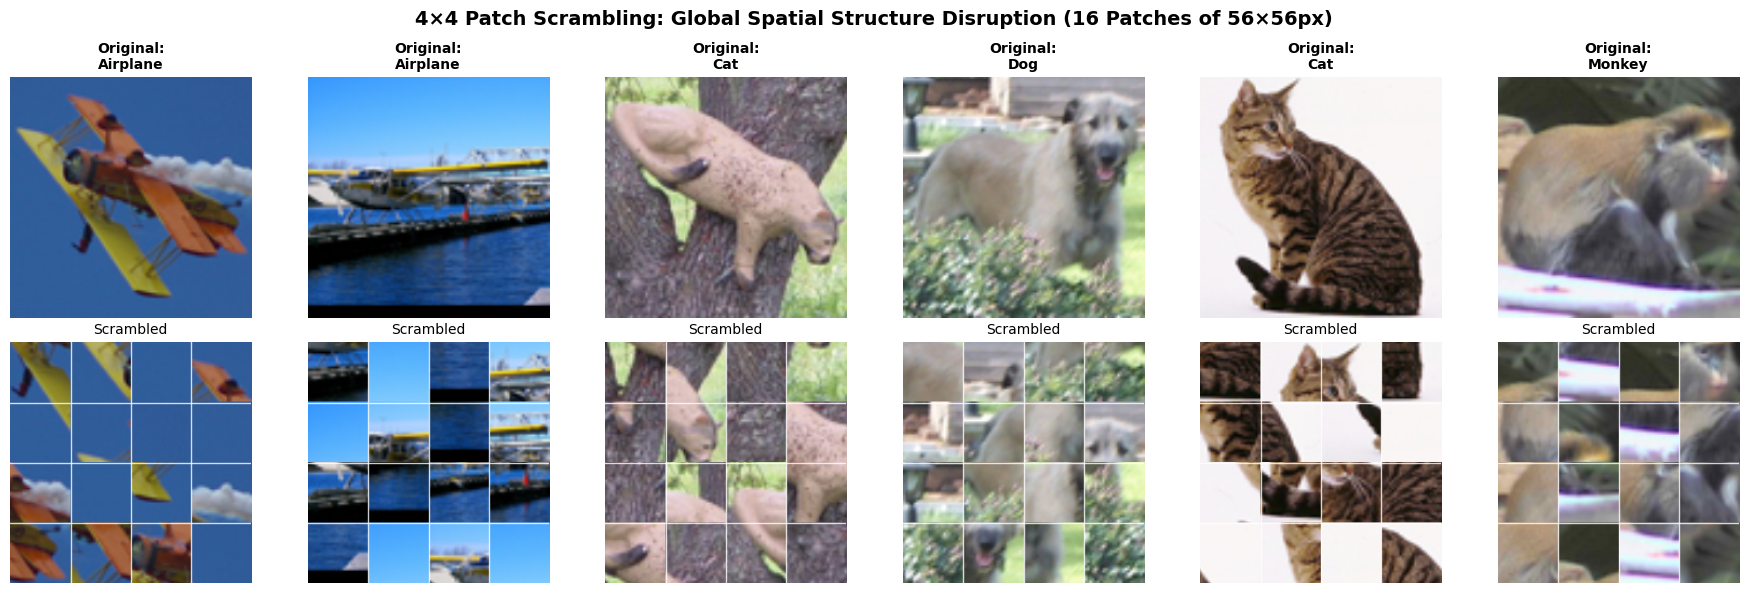

In [9]:
# Patch Shuffle Gallery with Overlaid Patch Boundaries
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
fig.suptitle("4×4 Patch Scrambling: Global Spatial Structure Disruption (16 Patches of 56×56px)", fontsize=14, fontweight='bold')
samples = [0, 50, 100, 150, 200, 250]

for j, s_idx in enumerate(samples):
    orig, lbl = eval_sub[s_idx]
    shuf = shuffled_images[s_idx]
    
    axes[0, j].imshow(orig.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[0, j].set_title(f"Original:\n{class_names[lbl].capitalize()}", fontsize=10, fontweight='bold')

    axes[1, j].imshow(shuf.permute(1, 2, 0).clamp(0, 1).numpy())
    axes[1, j].set_title("Scrambled", fontsize=10)
    
    # Overlay patch grid lines
    for line in [56, 112, 168]:
        axes[1, j].axhline(line, color='white', linewidth=1.0, alpha=0.8)
        axes[1, j].axvline(line, color='white', linewidth=1.0, alpha=0.8)

for ax in axes.flat: ax.axis('off')
axes[0, 0].set_ylabel("Clean Original", fontsize=11, fontweight='bold')
axes[1, 0].set_ylabel("4×4 Scrambled", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('../results/patch_shuffle_samples.png', dpi=200, bbox_inches='tight')
plt.show()


## 8. Evaluate Patch Scrambling Across Models
We evaluate:
- Shuffled Accuracy
- Accuracy Drop $\Delta$ ($= \text{Acc}_{\text{shuf}} - \text{Acc}_{\text{clean}}$)
- Prediction Consistency


In [10]:
shuffle_results = {}
shuffle_predictions = {}

for mkey in ['ResNet-50', 'ViT-B/16', 'CLIP', 'CLIP-ZS']:
    c_acc = np.mean(clean_preds[mkey] == eval_labels)
    if mkey == 'CLIP-ZS':
        s_preds = predict_clip_zs_batch(backbones['CLIP'], norms['CLIP'], shuffled_images, class_names)
    else:
        s_preds = predict_image_batch(backbones[mkey], norms[mkey], heads[mkey], shuffled_images)
        
    s_acc = np.mean(s_preds == eval_labels)
    s_cons = np.mean(s_preds == clean_preds[mkey])
    shuffle_predictions[mkey] = s_preds
    
    shuffle_results[mkey] = {
        'Clean Acc': c_acc,
        'Shuffled Acc': s_acc,
        'Accuracy Δ': s_acc - c_acc,
        'Consistency': s_cons
    }

df_shuffle = pd.DataFrame(shuffle_results).T
print("\n" + "="*75)
print("              PATCH SCRAMBLING EVALUATION SUMMARY")
print("="*75)
print(df_shuffle.to_string(float_format=lambda x: f"{x:+.4f}" if "Δ" in str(x) else f"{x:.4f}"))
print("="*75)



              PATCH SCRAMBLING EVALUATION SUMMARY
           Clean Acc  Shuffled Acc  Accuracy Δ  Consistency
ResNet-50     0.9700        0.8840     -0.0860       0.9020
ViT-B/16      0.9720        0.9080     -0.0640       0.9220
CLIP          0.9680        0.8000     -0.1680       0.8140
CLIP-ZS       0.9340        0.7760     -0.1580       0.7880


## 9. Patch Scrambling Breakdown Charts & Class Robustness
We plot:
1. Clean vs. Shuffled Accuracy
2. Prediction Consistency
3. Class-by-class accuracy retention (which classes survive based on local texture alone vs. which require global shape)


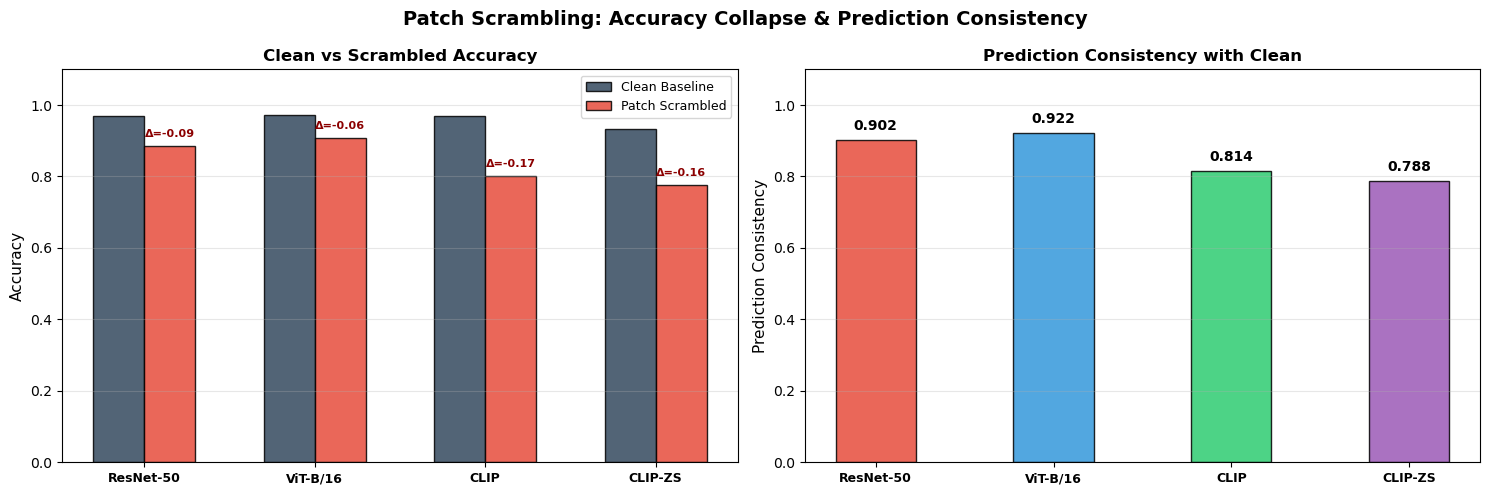

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Patch Scrambling: Accuracy Collapse & Prediction Consistency", fontsize=14, fontweight='bold')
m_names = list(shuffle_results.keys())
x = np.arange(len(m_names))
width = 0.3

# Panel 1: Accuracy comparison
ax = axes[0]
c_accs = df_shuffle['Clean Acc'].values
s_accs = df_shuffle['Shuffled Acc'].values
ax.bar(x - width/2, c_accs, width, label='Clean Baseline', color='#34495e', alpha=0.85, edgecolor='black')
ax.bar(x + width/2, s_accs, width, label='Patch Scrambled', color='#e74c3c', alpha=0.85, edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels([m.replace(' ', '\n') for m in m_names], fontsize=9, fontweight='bold')
ax.set_ylabel("Accuracy", fontsize=11)
ax.set_title("Clean vs Scrambled Accuracy", fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
for idx, (c, s) in enumerate(zip(c_accs, s_accs)):
    ax.text(idx + width/2, s + 0.02, f"Δ={s-c:+.2f}", ha='center', va='bottom', color='darkred', fontweight='bold', fontsize=8)

# Panel 2: Consistency
ax = axes[1]
cons_vals = df_shuffle['Consistency'].values
bars = ax.bar(x, cons_vals, width*1.5, color=['#e74c3c', '#3498db', '#2ecc71', '#9b59b6'], edgecolor='black', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels([m.replace(' ', '\n') for m in m_names], fontsize=9, fontweight='bold')
ax.set_ylabel("Prediction Consistency", fontsize=11)
ax.set_title("Prediction Consistency with Clean", fontsize=12, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, cons_vals):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/patch_shuffle_breakdown.png', dpi=200, bbox_inches='tight')
plt.show()


<Figure size 1400x550 with 0 Axes>

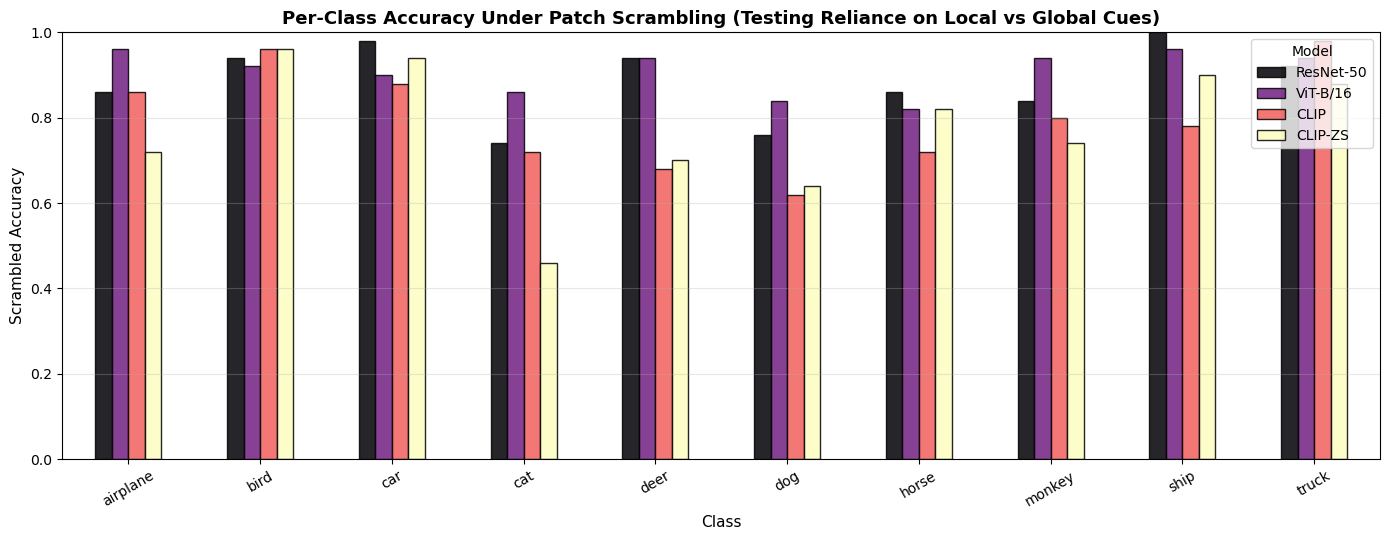

In [12]:
# Per-Class Accuracy Retention under Patch Scrambling
class_retention = {}
for mkey in ['ResNet-50', 'ViT-B/16', 'CLIP', 'CLIP-ZS']:
    s_p = shuffle_predictions[mkey]
    class_retention[mkey] = [np.mean((s_p == eval_labels)[eval_labels == c]) for c in range(10)]

df_retention = pd.DataFrame(class_retention, index=class_names)

plt.figure(figsize=(14, 5.5))
df_retention.plot(kind='bar', figsize=(14, 5.5), colormap='magma', edgecolor='black', alpha=0.85)
plt.title("Per-Class Accuracy Under Patch Scrambling (Testing Reliance on Local vs Global Cues)", fontsize=13, fontweight='bold')
plt.xlabel("Class", fontsize=11)
plt.ylabel("Scrambled Accuracy", fontsize=11)
plt.ylim(0, 1.0)
plt.xticks(rotation=30, fontsize=10)
plt.legend(title="Model", loc='upper right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../results/patch_shuffle_per_class_retention.png', dpi=200, bbox_inches='tight')
plt.show()


## 10. Cache Spatial Sensitivity Artifacts


In [13]:
torch.save(shuffled_images, '../cache/shuffled_images.pt')

# Save 16px and 32px translated images for representation analysis in Notebook 5
torch.save(translated_images[(16, 'right')], '../cache/trans_16px_images.pt')
torch.save(translated_images[(32, 'right')], '../cache/trans_32px_images.pt')

for mkey, preds in shuffle_predictions.items():
    safe = mkey.replace('/', '_').replace(' ', '_')
    np.save(f'../cache/shuffle_preds_{safe}.npy', preds)

df_shuffle.to_csv('../results/patch_shuffle.csv')
print("✅ Spatial sensitivity data and predictions successfully cached!")


✅ Spatial sensitivity data and predictions successfully cached!
